In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
def plot_thesis_results(dqn_file, a2c_file):
    # Load data
    df_dqn = pd.read_csv(dqn_file)
    df_a2c = pd.read_csv(a2c_file)

    fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
    
    # 1. Waiting Time Comparison (The Performance Metric)
    axs[0].plot(df_dqn['step'], df_dqn['avg_waiting_time'].rolling(window=10).mean(), label='DQN (Off-Policy)')
    axs[0].plot(df_a2c['step'], df_a2c['avg_waiting_time'].rolling(window=10).mean(), label='A2C (On-Policy)')
    axs[0].set_title("Average System Waiting Time (Lower is Better)")
    axs[0].axvspan(1000, 2500, color='red', alpha=0.1, label='Traffic Spike')
    axs[0].legend()

    # 2. Value Function V(s) (The Confidence Metric)
    axs[1].plot(df_dqn['step'], df_dqn['value_estimate'], label='DQN V(s)')
    axs[1].plot(df_a2c['step'], df_a2c['value_estimate'], label='A2C V(s)')
    axs[1].set_title("State Value Estimate (Agent's Internal Evaluation)")
    axs[1].legend()

    # 3. Policy Choice (The Adaptation Metric)
    # We use a scatter plot to show which corridor the agent prefers
    axs[2].scatter(df_dqn['step'], df_dqn['optimum_action'], alpha=0.3, label='DQN Preference', marker='|')
    axs[2].scatter(df_a2c['step'], df_a2c['optimum_action'], alpha=0.3, label='A2C Preference', marker='_')
    # axs[2].set_yticks()
    axs[2].set_yticklabels(['0: N-S Green', '1: E-W Green'])
    axs[2].set_title("Policy Decision over Time")
    axs[2].legend()

    plt.xlabel("Simulation Step")
    plt.tight_layout()
    plt.savefig("Thesis_Comparison_Plot.png")
    plt.show()

/var/folders/q8/0w_q732j6qg09cd39b3sc3d40000gn/T/ipykernel_36323/4234292467.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_yticklabels(['0: N-S Green', '1: E-W Green'])


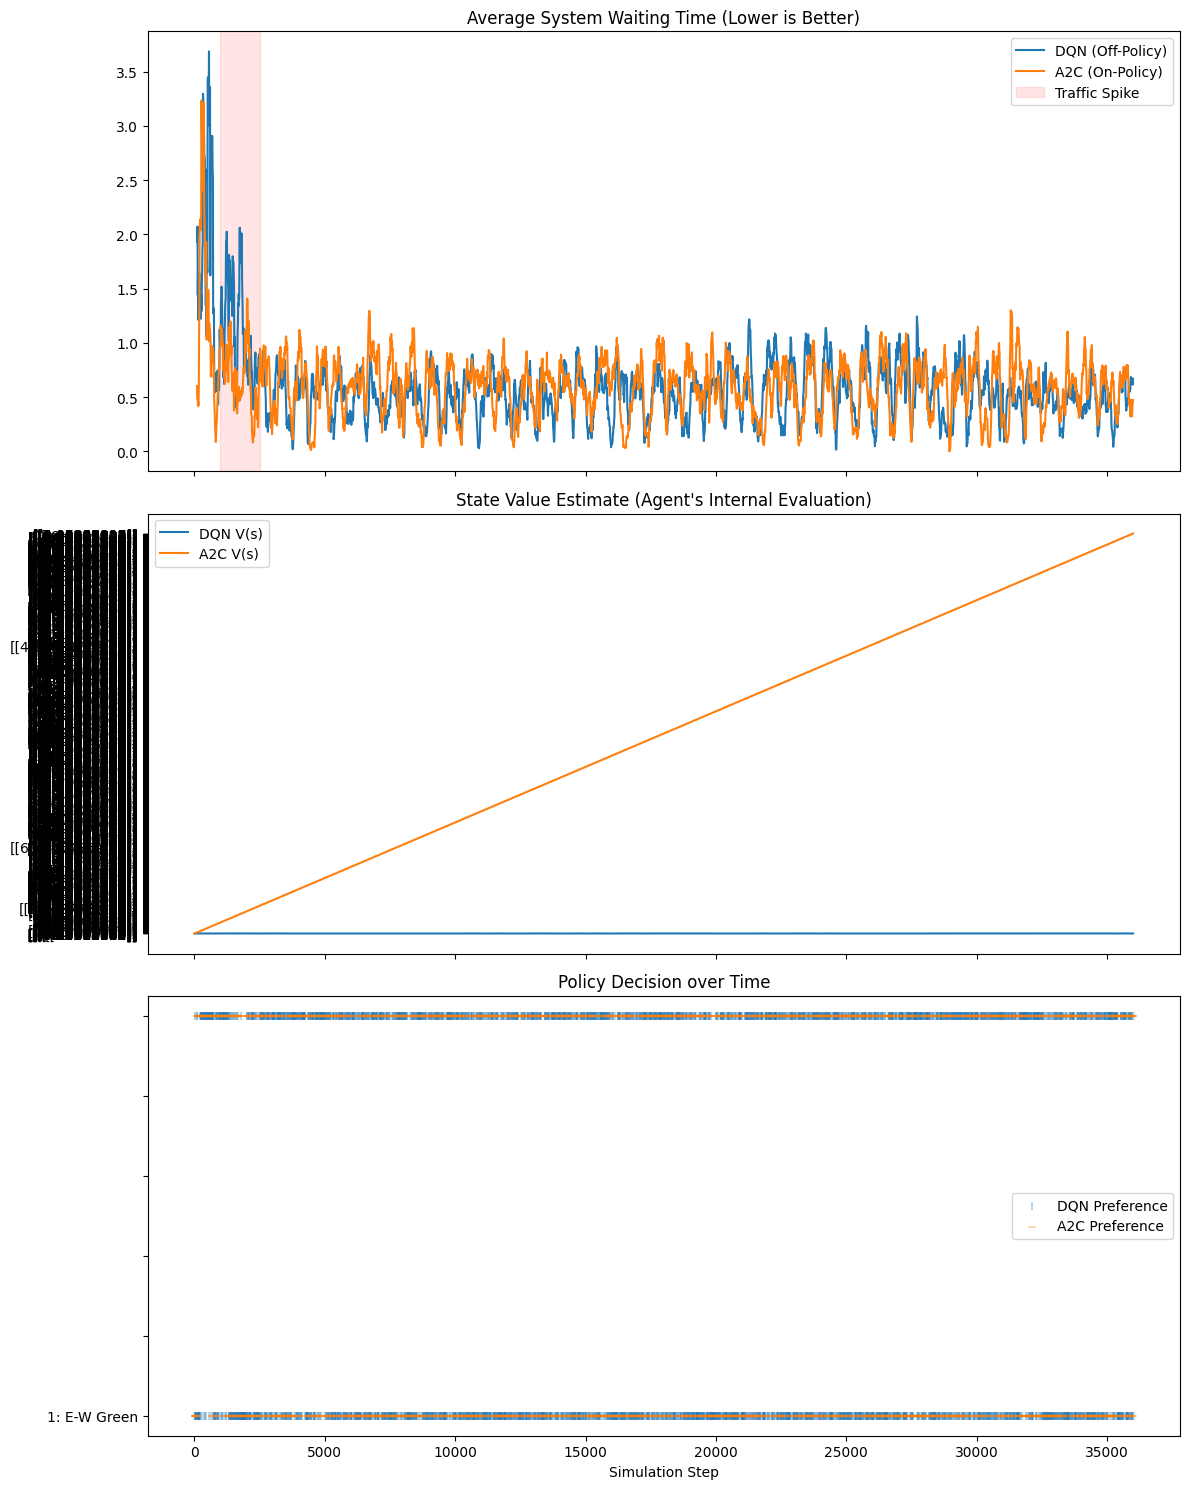

In [16]:
plot_thesis_results("results_DQN_adaptive_random.csv", "results_SARSA_adaptive_random.csv")

Loading data from results_DQN_adaptive_random.csv...
✅ Success! Plot saved as results_DQN_adaptive_random_learning_curve_analysis.png


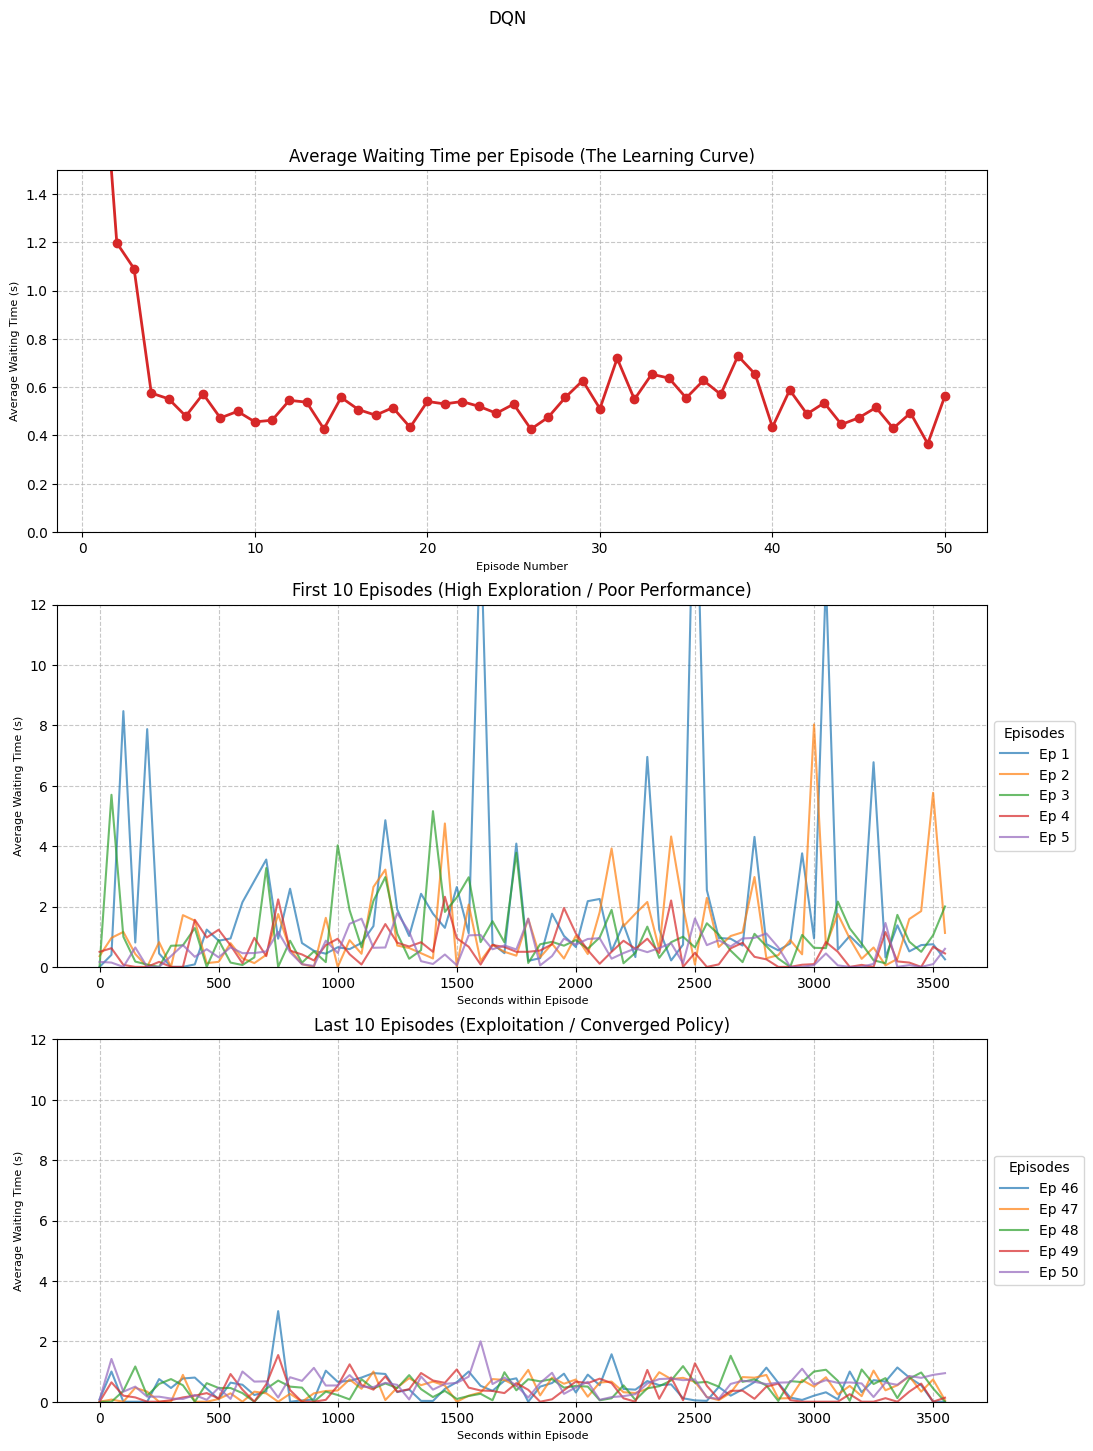

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_learning_progress(csv_file):
    print(f"Loading data from {csv_file}...")
    df = pd.read_csv(csv_file)
    
    # --- Data Preparation ---
    # Your CSV logs total steps (n_calls). We need to convert that into 
    # "Step within Episode" so all episodes start at 0 on the X-axis for charts 2 & 3.
    df['step_in_episode'] = df.groupby('episode')['step'].transform(lambda x: x - x.min())

    # NEW: Transform steps to seconds
    DELTA_TIME = 5
    df['seconds_in_episode'] = df['step_in_episode'] * DELTA_TIME
    
    # Set up the 3-panel figure
    fig, axs = plt.subplots(3, 1, figsize=(12, 16))
    
    # ---------------------------------------------------------
    # Chart 1: Average Waiting Time PER EPISODE (Learning Curve)
    # ---------------------------------------------------------
    # Group the data by episode and calculate the mean waiting time for the entire hour
    ep_avg = df.groupby('episode')['avg_waiting_time'].mean()
    
    axs[0].plot(ep_avg.index, ep_avg.values, marker='o', color='tab:red', linewidth=2)
    axs[0].set_title('Average Waiting Time per Episode (The Learning Curve)')
    axs[0].set_xlabel('Episode Number', fontsize=8)
    axs[0].set_ylabel('Average Waiting Time (s)', fontsize=8)
    axs[0].grid(True, linestyle='--', alpha=0.7)
    axs[0].set_ylim(0, 1.5)

    # ---------------------------------------------------------
    # Chart 2: Intra-Episode Dynamics for FIRST 10 EPISODES
    # ---------------------------------------------------------
    first_episodes = df[df['episode'] <= 5]
    
    for ep in range(1, 6):
        ep_data = first_episodes[first_episodes['episode'] == ep]
        if not ep_data.empty:
            axs[1].plot(ep_data['seconds_in_episode'], ep_data['avg_waiting_time'], label=f'Ep {ep}', alpha=0.7)
            
    axs[1].set_title('First 10 Episodes (High Exploration / Poor Performance)')
    axs[1].set_xlabel('Seconds within Episode', fontsize=8)
    axs[1].set_ylim(0, 12)
    axs[1].set_ylabel('Average Waiting Time (s)', fontsize=8)
    # axs[1].axvspan(1000, 2500, color='red', alpha=0.1, label='Traffic Spike')
    axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Episodes")
    axs[1].grid(True, linestyle='--', alpha=0.7)

    # ---------------------------------------------------------
    # Chart 3: Intra-Episode Dynamics for LAST 10 EPISODES
    # ---------------------------------------------------------
    total_episodes = df['episode'].max()
    last_10 = df[df['episode'] > total_episodes - 5]
    
    for ep in range(total_episodes - 4, total_episodes + 1):
        ep_data = last_10[last_10['episode'] == ep]
        if not ep_data.empty:
            axs[2].plot(ep_data['seconds_in_episode'], ep_data['avg_waiting_time'], label=f'Ep {ep}', alpha=0.7)
            
    axs[2].set_title(f'Last 10 Episodes (Exploitation / Converged Policy)')
    axs[2].set_xlabel('Seconds within Episode', fontsize=8)
    axs[2].set_ylim(0, 12)
    axs[2].set_ylabel('Average Waiting Time (s)', fontsize=8)
    # axs[2].axvspan(1000, 2500, color='red', alpha=0.1, label='Traffic Spike')
    axs[2].legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Episodes")

    axs[2].grid(True, linestyle='--', alpha=0.7)

    # Save and display
    # plt.tight_layout()
    model_description = csv_file.replace(".csv", "")

    model_type = model_description.split("_")[1]
    output_image = f"{model_description}_learning_curve_analysis.png"
    fig.suptitle(model_type)
    plt.savefig(output_image, bbox_inches='tight', dpi=150)
    print(f"✅ Success! Plot saved as {output_image}")
    plt.show()

# Run the function on your newly generated CSV:
# Make sure to replace this with your actual CSV filename!
plot_learning_progress('results_DQN_adaptive_random.csv')